In [1]:
import pandas as pd

df = pd.DataFrame({

    "RPM":[
        100,100,
        200,200,
        300,300,

        100,100,
        200,200,
        300,300,

        100,100,
        200,200,
        300,300
    ],

    "Aeration":[
        0.5,0.5,
        0.5,0.5,
        0.5,0.5,

        1.0,1.0,
        1.0,1.0,
        1.0,1.0,

        1.5,1.5,
        1.5,1.5,
        1.5,1.5
    ],

    "Biomass":[
        5.1,4.9,
        6.8,6.6,
        6.5,6.3,

        6.0,6.2,
        8.9,8.7,
        9.5,9.3,

        7.0,7.2,
        10.2,10.0,
        10.0,9.8
    ]
})

df

,RPM,Aeration,Biomass
0,100,0.5,5.1
1,100,0.5,4.9
2,200,0.5,6.8
3,200,0.5,6.6
4,300,0.5,6.5
5,300,0.5,6.3
6,100,1.0,6.0
7,100,1.0,6.2
8,200,1.0,8.9
9,200,1.0,8.7


In [25]:
import pandas as pd

df = pd.DataFrame({

    "RPM":[
        100,100,
        200,200,
        300,300,

        100,100,
        200,200,
        300,300,

        100,100,
        200,200,
        300,300
    ],

    "Aeration":[
        0.5,0.5,
        0.5,0.5,
        0.5,0.5,

        1.0,1.0,
        1.0,1.0,
        1.0,1.0,

        1.5,1.5,
        1.5,1.5,
        1.5,1.5
    ],

    "Biomass":[
        4.9,5.1,
        6.9,7.1,
        5.8,6.2,

        5.9,6.1,
        8.8,9.2,
        9.8,10.2,

        6.9,7.1,
        10.8,11.2,
        14.8,15.2
    ]
})

df

,RPM,Aeration,Biomass
0,100,0.5,4.9
1,100,0.5,5.1
2,200,0.5,6.9
3,200,0.5,7.1
4,300,0.5,5.8
5,300,0.5,6.2
6,100,1.0,5.9
7,100,1.0,6.1
8,200,1.0,8.8
9,200,1.0,9.2


In [26]:
means = (
    df.pivot_table(
        values="Biomass",
        index="Aeration",
        columns="RPM",
        aggfunc="mean"
    )
)

means

RPM,100,200,300
Aeration,,,
0.5,5.0,7.0,6.0
1.0,6.0,9.0,10.0
1.5,7.0,11.0,15.0


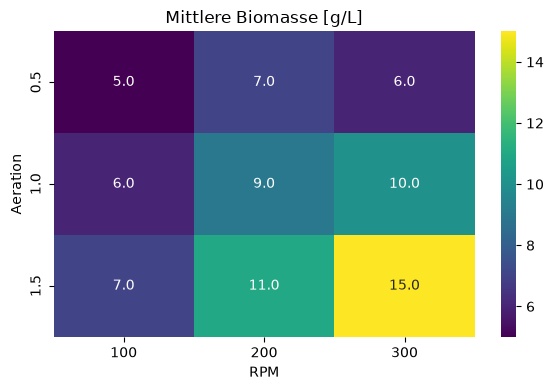

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    means,
    annot=True,
    fmt=".1f",
    cmap="viridis"
)

plt.title(
    "Mittlere Biomasse [g/L]"
)

plt.tight_layout()

plt.show()

In [30]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

model_cat = ols(
    "Biomass ~ C(RPM)*C(Aeration)",
    data=df
).fit()

anova_cat = anova_lm(
    model_cat,
    typ=2
)

anova_cat["MS"] = (
    anova_cat["sum_sq"]
    /
    anova_cat["df"]
)

anova_cat.round(3)
anova_cat

,sum_sq,df,F,PR(>F),MS
C(RPM),59.111111,2.0,554.166667,3.778060e-10,29.555556
C(Aeration),75.111111,2.0,704.166667,1.295589e-10,37.555556
C(RPM):C(Aeration),26.222222,4.0,122.916667,7.586650e-08,6.555556
Residual,0.480000,9.0,NaN,NaN,0.053333


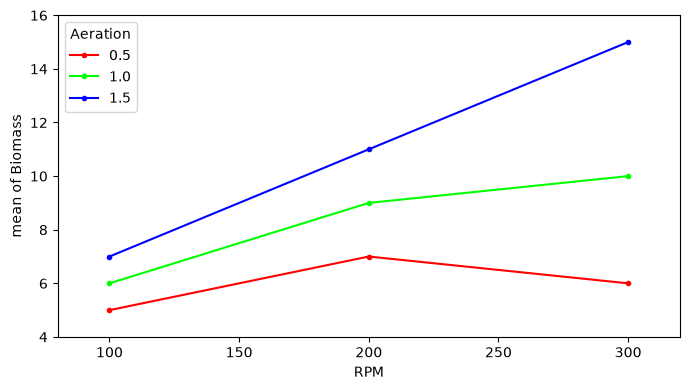

In [38]:
from statsmodels.graphics.factorplots import interaction_plot

fig, ax = plt.subplots(
    figsize=(7,4)
)

interaction_plot(
    df["RPM"],
    df["Aeration"],
    df["Biomass"],
    ax=ax
)

plt.tight_layout()
#plt.savefig("biomass_interaction_plot.pdf",bbox_inches="tight")
plt.show()

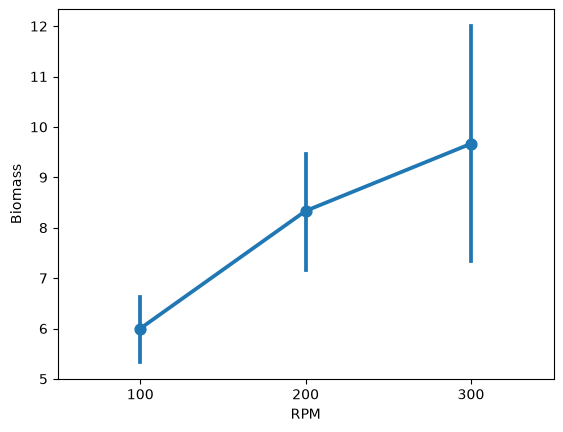

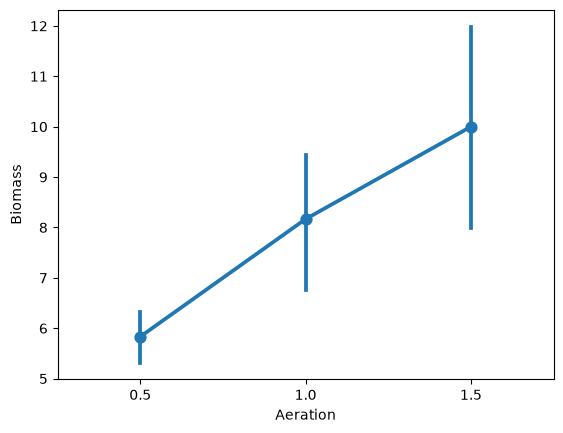

In [19]:
sns.pointplot(
    data=df,
    x="RPM",
    y="Biomass",
    errorbar=("ci",95)
)

plt.show()

sns.pointplot(
    data=df,
    x="Aeration",
    y="Biomass",
    errorbar=("ci",95)
)

plt.show()

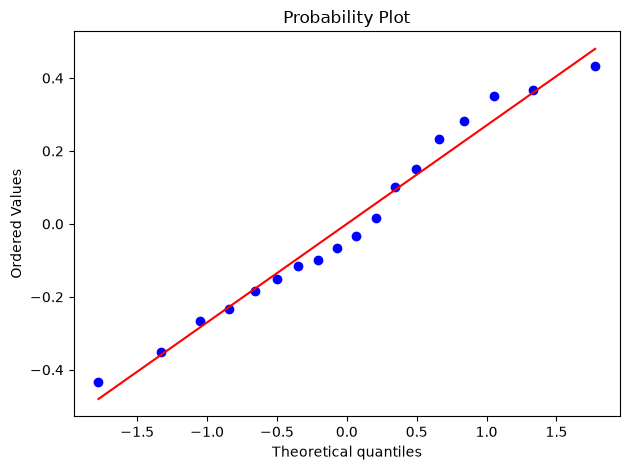

In [39]:
from scipy import stats

stats.probplot(
    model_quad.resid,
    dist="norm",
    plot=plt
)

plt.tight_layout()
#plt.savefig("biomass_qqplot.pdf",bbox_inches="tight")
plt.show()

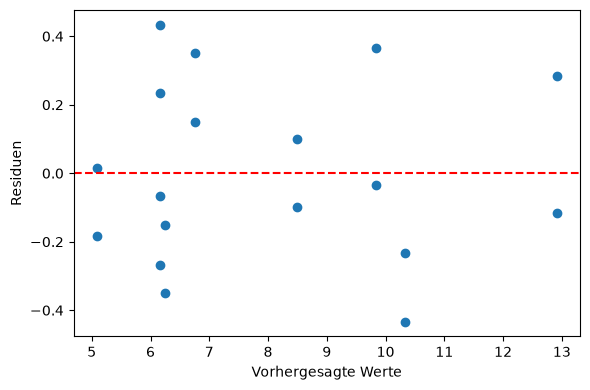

In [41]:
plt.figure(figsize=(6,4))

plt.scatter(
    model_quad.fittedvalues,
    model_quad.resid
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Vorhergesagte Werte")
plt.ylabel("Residuen")

plt.tight_layout()
#plt.savefig("biomass_residuals_vs_fits.pdf",bbox_inches="tight")
plt.show()

In [20]:
model_quad = ols(
    """
    Biomass
    ~ RPM
    + Aeration
    + I(RPM**2)
    + I(Aeration**2)
    + RPM:Aeration
    """,
    data=df
).fit()

print(
    model_quad.summary()
)

                            OLS Regression Results                            
Dep. Variable:                Biomass   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     224.8
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           2.01e-11
Time:                        14:58:44   Log-Likelihood:               -0.65402
No. Observations:                  18   AIC:                             13.31
Df Residuals:                      12   BIC:                             18.65
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.6667      0.884  

Das Modell lautet

$y = \beta_0 + \beta_1 RPM + \beta_2 Aeration + \beta_{11} RPM^2 + \beta_{22} Aeration^2 + \beta_{12}(RPM\cdot Aeration)$

In [21]:
print(
    "R² =",
    round(model_quad.rsquared,3)
)

R² = 0.989


In [22]:
import numpy as np

rpm_grid = np.linspace(
    100,
    300,
    50
)

aer_grid = np.linspace(
    0.5,
    1.5,
    50
)

R,A = np.meshgrid(
    rpm_grid,
    aer_grid
)

grid = pd.DataFrame({
    "RPM":R.ravel(),
    "Aeration":A.ravel()
})

grid["Pred"] = (
    model_quad.predict(grid)
)

Z = (
    grid["Pred"]
    .values
    .reshape(R.shape)
)


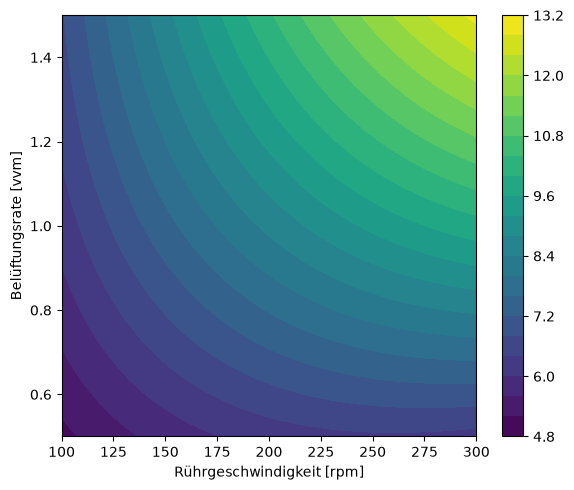

In [23]:
plt.figure(figsize=(6,5))

contour = plt.contourf(
    R,
    A,
    Z,
    levels=20,
    cmap="viridis"
)

plt.colorbar(contour)

plt.xlabel(
    "Rührgeschwindigkeit [rpm]"
)

plt.ylabel(
    "Belüftungsrate [vvm]"
)

plt.tight_layout()

plt.show()

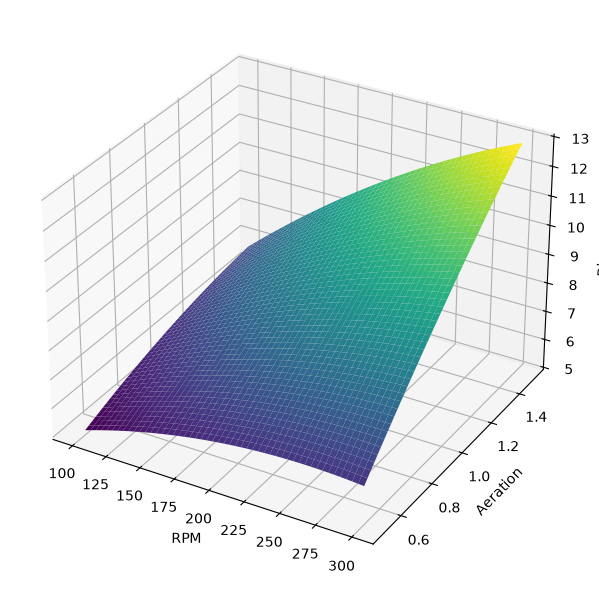

In [24]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(
    figsize=(8,6)
)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot_surface(
    R,
    A,
    Z,
    cmap="viridis"
)

ax.set_xlabel("RPM")
ax.set_ylabel("Aeration")
ax.set_zlabel("Biomass")

plt.tight_layout()

plt.show()

In [13]:
grid.sort_values(
    "Pred",
    ascending=False
).head(10)

,RPM,Aeration,Pred
2491,267.346939,1.500000,10.370163
2490,263.265306,1.500000,10.369719
2492,271.428571,1.500000,10.366553
2489,259.183673,1.500000,10.365221
2493,275.510204,1.500000,10.358890
2488,255.102041,1.500000,10.356669
2494,279.591837,1.500000,10.347172
2440,263.265306,1.479592,10.344771
2441,267.346939,1.479592,10.344632
2487,251.020408,1.500000,10.344063
